In [ ]:
import torch
import torchvision
import matplotlib.pyplot as plt
import os
import zipfile

from pathlib import Path
from torch.utils.tensorboard import SummaryWriter
from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular import data_setup, engine

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
def set_seeds(seed : int = 42):

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [5]:
train_dir = image_path / "train"
test_dir = image_path / "test"

normalize = transforms.Normalize(
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225]
)

manual_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

automatic_transform = weights.transforms()

print(f"Transform: {manual_transform}")
print(f"Transform: {automatic_transform}")

train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = manual_transform,
    batch_size = 32
)

train_dataloaders, test_dataloaders, class_namess = data_setup.create_dataloader(
    train_dir = train_dir,
    test_dir = test_dir,
    transform = automatic_transform,
    batch_size = 32
)

train_dataloader, test_dataloader, class_names, train_dataloaders, test_dataloaders, class_namess

Transform: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)
Transform: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


(<torch.utils.data.dataloader.DataLoader at 0x1931f441a30>,
 ['pizza', 'steak', 'sushi'],
 ['pizza', 'steak', 'sushi'])

In [6]:
model = torchvision.models.efficientnet_b0(weights = weights).to(device)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [7]:
for param in model.features.parameters():
    param.requires_grad = False

set_seeds()

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace = True),
    nn.Linear(
        in_features = 1280,
        out_features = len(class_names),
        bias = True
    )
).to(device)

In [8]:
from torchinfo import summary

# Get a summary of the model (uncomment for full output)
summary(model, 
         input_size=(32, 3, 224, 224), # make sure this is "input_size", not "input_shape" (batch_size, color_channels, height, width)
         verbose=0,
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"]
 )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    params = model.parameters(),
    lr = 0.001
)

In [11]:
from going_modular.engine import train_step, test_step
from typing import Dict, List
from tqdm.auto import tqdm

def train(model:torch.nn.Module, train_dataloader:torch.utils.data.DataLoader, test_dataloader:torch.utils.data.DataLoader, loss_fn:torch.nn.Module, optimizer:torch.optim.Optimizer,epochs:int, device:torch.device) -> Dict[str, List]:

    results = {
        "train_loss" : [],
        "train_acc" : [],
        "test_loss" : [],
        "test_acc" : []
    }

    for epoch in tqdm(range(epochs)):

        train_loss, train_acc = train_step(model=model, dataloader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, device=device)

        test_loss, test_acc = test_step(model=model, dataloader=test_dataloader, loss_fn=loss_fn, device=device)

        print(
            f"Epoch : {epoch+1} |"
            f"train loss : {train_loss:.4f} |"
            f"train acc : {train_acc:.4f} |"
            f"test loss : {test_loss:.4f} |"
            f"test acc : {test_acc:.4f}" 
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        writer.add_scalars(
            main_tag = "Loss",
            tag_scalar_dict = {
                "train_loss" : train_loss,
                "test_loss" : test_loss
            },
            global_step = epoch
        )

        writer.add_scalars(
            main_tag = "Accuracy",
            tag_scalar_dict = {
                "train_acc" : train_acc,
                "test_acc" : test_acc
            },
            global_step = epoch
        )

        writer.add_graph(
            model = model,
            input_to_model = torch.randn(32, 3, 224, 224).to(device)
        )
    
    writer.close()

    return results

In [12]:
set_seeds()

results = train(
    model = model,
    train_dataloader = train_dataloaders,
    test_dataloader = test_dataloaders,
    optimizer = optimizer,
    loss_fn = loss_fn,
    epochs = 5,
    device = device
)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 1 |train loss : 1.0962 |train acc : 0.3906 |test loss : 0.9145 |test acc : 0.5909


 20%|██        | 1/5 [00:33<02:12, 33.09s/it]

Epoch : 2 |train loss : 0.9047 |train acc : 0.6445 |test loss : 0.7884 |test acc : 0.8258


 40%|████      | 2/5 [01:00<01:29, 29.81s/it]

...

 60%|██████    | 3/5 [01:28<00:58, 29.05s/it]

Epoch : 4 |train loss : 0.6849 |train acc : 0.8594 |test loss : 0.6739 |test acc : 0.8049


 80%|████████  | 4/5 [01:54<00:27, 27.59s/it]

Epoch : 5 |train loss : 0.7080 |train acc : 0.7266 |test loss : 0.6793 |test acc : 0.7737


100%|██████████| 5/5 [02:16<00:00, 27.21s/it]


In [13]:
results

{'train_loss': [1.096216820180416,
  0.9046593308448792,
  0.8096034303307533,
  0.6848845928907394,
  0.7080142684280872],
 'train_acc': [0.390625, 0.64453125, 0.734375, 0.859375, 0.7265625],
 'test_loss': [0.9144526720046997,
  0.7883840401967367,
  0.6769014398256937,
  0.6739373604456583,
  0.6793407599131266],
 'test_acc': [0.5909090909090909,
  0.8257575757575758,
  0.8863636363636364,
  0.8049242424242425,
  0.7736742424242425]}

In [15]:
from datetime import datetime
import os

def create_writer(experiment_name:str, model_name:str, extra:str=None) -> torch.utils.tensorboard.writer.SummaryWriter():

    timestamp = datetime.now().strftime("%Y-%m-%d")

    if extra:
        log_dir = os.path.join("runs", timestamp, experiment_name, model_name, extra)
    else:
        log_dir = os.path.join("runs", timestamp, experiment_name, model_name)

    print(f"[INFO] Created SummaryWriter, saving to: {log_dir}...")
    return SummaryWriter(log_dir = log_dir)

In [16]:
example_writer = create_writer(
    experiment_name = "data_10_percent",
    model_name = "effnetb0",
    extra = "5_epochs"
)

[INFO] Created SummaryWriter, saving to: runs\2026-03-02\data_10_percent\effnetb0\5_epochs...


In [17]:
from going_modular.engine import train_step, test_step
from typing import Dict, List
from tqdm.auto import tqdm

def train(model:torch.nn.Module, train_dataloader:torch.utils.data.DataLoader, test_dataloader:torch.utils.data.DataLoader, loss_fn:torch.nn.Module, optimizer:torch.optim.Optimizer,epochs:int, device:torch.device, writer:torch.utils.tensorboard.SummaryWriter) -> Dict[str, List]:

    results = {
        "train_loss" : [],
        "train_acc" : [],
        "test_loss" : [],
        "test_acc" : []
    }

    for epoch in tqdm(range(epochs)):

        train_loss, train_acc = train_step(model=model, dataloader=train_dataloader, loss_fn=loss_fn, optimizer=optimizer, device=device)

        test_loss, test_acc = test_step(model=model, dataloader=test_dataloader, loss_fn=loss_fn, device=device)

        print(
            f"Epoch : {epoch+1} |"
            f"train loss : {train_loss:.4f} |"
            f"train acc : {train_acc:.4f} |"
            f"test loss : {test_loss:.4f} |"
            f"test acc : {test_acc:.4f}" 
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        if writer:
            writer.add_scalars(
                main_tag = "Loss",
                tag_scalar_dict = {
                    "train_loss" : train_loss,
                    "test_loss" : test_loss
                },
                global_step = epoch
            )

            writer.add_scalars(
                main_tag = "Accuracy",
                tag_scalar_dict = {
                    "train_acc" : train_acc,
                    "test_acc" : test_acc
                },
                global_step = epoch
            )

            writer.add_graph(
                model = model,
                input_to_model = torch.randn(32, 3, 224, 224).to(device)
            )
    
            writer.close()
        else:
            pass

    return results

In [5]:
import os
import zipfile

from pathlib import Path

import requests

def download_data(source: str, 
                  destination: str,
                  remove_source: bool = True) -> Path:
    # Setup path to data folder
    data_path = Path("data/")
    image_path = data_path / destination

    # If the image folder doesn't exist, download it and prepare it... 
    if image_path.is_dir():
        print(f"[INFO] {image_path} directory exists, skipping download.")
    else:
        print(f"[INFO] Did not find {image_path} directory, creating one...")
        image_path.mkdir(parents=True, exist_ok=True)
        
        # Download pizza, steak, sushi data
        target_file = Path(source).name
        with open(data_path / target_file, "wb") as f:
            request = requests.get(source)
            print(f"[INFO] Downloading {target_file} from {source}...")
            f.write(request.content)

        # Unzip pizza, steak, sushi data
        with zipfile.ZipFile(data_path / target_file, "r") as zip_ref:
            print(f"[INFO] Unzipping {target_file} data...") 
            zip_ref.extractall(image_path)

        # Remove .zip file
        if remove_source:
            os.remove(data_path / target_file)
    
    return image_path

In [7]:
train_dir_10_percent = data_10_percent_path / "train"
train_dir_20_percent = data_20_percent_path / "train"

test_dir = data_10_percent_path / "test"


print(f"Training directory 10%: {train_dir_10_percent}")
print(f"Training directory 20%: {train_dir_20_percent}")
print(f"Testing directory: {test_dir}")

Training directory 10%: data\pizza_steak_sushi\train
Training directory 20%: data\pizza_steak_sushi_20_percent\train
Testing directory: data\pizza_steak_sushi\test


In [8]:
normalize = transforms.Normalize(
    mean = [0.485, 0.456, 0.406],
    std = [0.229, 0.224, 0.225]
)

transforming = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

In [9]:
BATCH_SIZE = 32

train_data_10, test_data, class_names = data_setup.create_dataloader(
    train_dir = train_dir_10_percent,
    test_dir = test_dir,
    transform = transforming,
    batch_size = BATCH_SIZE,
)

train_data_20, test_data, class_names = data_setup.create_dataloader(
    train_dir = train_dir_20_percent,
    test_dir = test_dir,
    transform = transforming,
    batch_size = BATCH_SIZE,
)

print(f"Number of batches of size {BATCH_SIZE} in 10 percent training data: {len(train_data_10)}")
print(f"Number of batches of size {BATCH_SIZE} in 20 percent training data: {len(train_data_20)}")
print(f"Number of batches of size {BATCH_SIZE} in testing data: {len(test_data)} (all experiments will use the same test set)")
print(f"Number of classes: {len(class_names)}, class names: {class_names}")

Number of batches of size 32 in 10 percent training data: 8
Number of batches of size 32 in 20 percent training data: 15
Number of batches of size 32 in testing data: 3 (all experiments will use the same test set)
Number of classes: 3, class names: ['pizza', 'steak', 'sushi']


In [10]:
#1408

out = len(class_names)

def create_effnetb0():

    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    effnetb0 = torchvision.models.efficientnet_b0(weights = weights).to(device)

    for param in effnetb0.features.parameters():
        param.requires_grad = False

    set_seeds()

    effnetb0.classifier = nn.Sequential(
        nn.Dropout(p = 0.2),
        nn.Linear(
            in_features = 1280,
            out_features = out
        )
    ).to(device)

    effnetb0.name = "effnetb0"
    print(f"Created {effnetb0.name} model")
    return effnetb0

def create_effnetb2():

    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    effnetb2 = torchvision.models.efficientnet_b2(weights = weights).to(device)

    for param in effnetb2.features.parameters():
        param.requires_grad = False

    set_seeds()

    effnetb2.classifier = nn.Sequential(
        nn.Dropout(p = 0.2),
        nn.Linear(
            in_features = 1408,
            out_features = out
        )
    ).to(device)

    effnetb2.name = "effnetb2"
    print(f"Created {effnetb2.name} model")
    return effnetb2

In [37]:
effnetb0 = create_effnetb0()

summary(
    model = effnetb0,
    input_size = (32, 3, 224, 224),
    col_names = ["input_size", "output_size", "num_params", "trainable"],
    col_width = 20,
    row_settings = ["var_names"]
)

Created effnetb0 model


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [38]:
effnetb2 = create_effnetb2()

summary(
    model = effnetb2,
    input_size = (32, 3, 224, 224),
    col_names = ["input_size", "output_size", "num_params", "trainable"],
    col_width = 20,
    row_settings = ["var_names"]
)

Created effnetb2 model


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                                      [32, 3, 224, 224]    [32, 1408, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)                              [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                                       [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                                  [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─SiLU (2)                                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─Sequential (1)                                        [32, 32, 112, 112]   [32, 

In [40]:
num_epochs = [5, 10]

models = ["effnetb0", "effnetb2"]

train_dataloaders = {
    "data_10_percent" : train_data_10,
    "data_20_percent" : train_data_20
}

In [45]:
from going_modular.utils import save_model

set_seeds(seed = 42)

exp_no = 0

for dataloader_name, train_dataloader in train_dataloaders.items():

    for epoch in num_epochs:

        for model_name in models:

            exp_no += 1
            print(f"[INFO] Experiment number: {exp_no}")
            print(f"[INFO] Model: {model_name}")
            print(f"[INFO] DataLoader: {dataloader_name}")
            print(f"[INFO] Number of epochs: {epoch}")

            if model_name == "effnetb0":
                model = create_effnetb0()
            else:
                model = create_effnetb2()

            loss_fn = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.001)

            train(
                model = model,
                train_dataloader = train_dataloader,
                test_dataloader = test_data,
                optimizer = optimizer,
                loss_fn = loss_fn,
                epochs = epoch,
                device = device,
                writer = create_writer(
                    experiment_name = dataloader_name,
                    model_name = model_name,
                    extra = f"{epoch}_epochs"
                )
            )

            save_filepath = f"07_{model_name}_{dataloader_name}_{epoch}_epochs.pth"
            save_model(
                model = model,
                target_dir = "models",
                model_name = save_filepath
            )

            print("-"*50 + "\n")

[INFO] Experiment number: 1
[INFO] Model: effnetb0
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 5
Created effnetb0 model
[INFO] Created SummaryWriter, saving to: runs\2026-03-02\data_10_percent\effnetb0\5_epochs...


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch : 1 |train loss : 1.0528 |train acc : 0.4961 |test loss : 0.9217 |test acc : 0.4678


 20%|██        | 1/5 [00:23<01:33, 23.38s/it]

Epoch : 2 |train loss : 0.9416 |train acc : 0.5586 |test loss : 0.8404 |test acc : 0.5492


...

Epoch : 9 |train loss : 0.3261 |train acc : 0.9417 |test loss : 0.4245 |test acc : 0.8977


 90%|█████████ | 9/10 [03:41<00:24, 24.64s/it]

Epoch : 10 |train loss : 0.3512 |train acc : 0.8729 |test loss : 0.3682 |test acc : 0.9384


100%|██████████| 10/10 [04:06<00:00, 24.65s/it]

[INFO] saving model to models\07_effnetb2_data_20_percent_10_epochs.pth
--------------------------------------------------



In [48]:
%reload_ext tensorboard
%tensorboard --logdir runs

Reusing TensorBoard on port 6007 (pid 4364), started 0:00:09 ago. (Use '!kill 4364' to kill it.)

In [11]:
best_model_path = "models/07_effnetb2_data_20_percent_10_epochs.pth"

best_model = create_effnetb2()

best_model.load_state_dict(torch.load(best_model_path))

Created effnetb2 model


<All keys matched successfully>

In [12]:
from pathlib import Path

effnetb2_model_size = Path(best_model_path).stat().st_size // (1024*1024)

print(f"Feature extractor model size {effnetb2_model_size} MB")

Feature extractor model size 29 MB


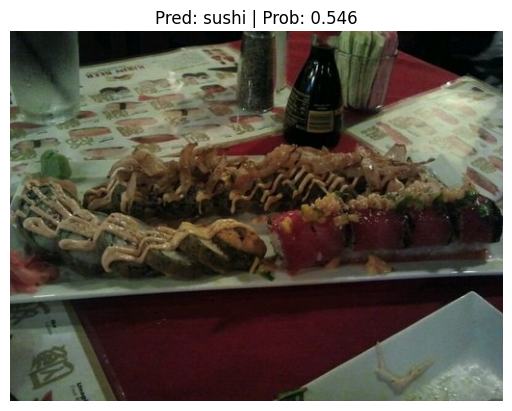

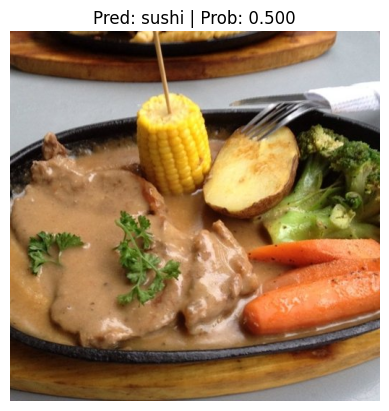

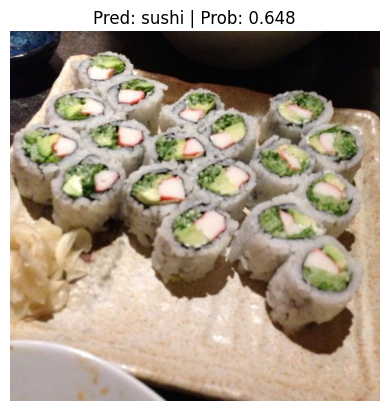

In [13]:
from going_modular.predictions import pred_and_plot_image
from pathlib import Path

import random

num_img_plot = 3

test_img_path_list = list(Path(data_20_percent_path / "test").glob("*/*.jpg"))
test_sample = random.sample(population = test_img_path_list, k = num_img_plot)

for image_path in test_sample:
    pred_and_plot_image(
        model = best_model,
        image_path = image_path,
        class_names = class_names,
        image_size = (224,224)
    )

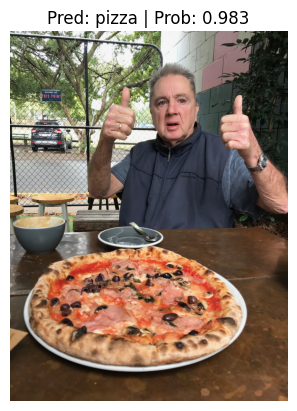

In [14]:
import requests

custom = Path("data/pizza.jpeg")

pred_and_plot_image(
    model = best_model,
    image_path = custom,
    class_names = class_names
)